# 14 - σ8 and Δχ² along the ω_dm,tot ridge

At fixed ω_dm,tot = ω_cdm(1 + f_acc) (notebook 13), f_acc only sets how much of the dark matter becomes
daughters, and the kick sets how far they free-stream. This measures, per mass, how much that changes
σ8 and the observables: how flat is the ridge the high-mass chains run along?

1. CLASS grid: masses × f_acc at fixed ω_dm,tot and fixed ΛCDM parameters.
2. σ8 (from P_m) and σ8_cb (from P_cb) along the ridge.
3. Where in k the suppression sits.
4. Approximate Δχ² against f_acc → 0 (`accdm_nb.chi2_parts`). ΛCDM stays fixed, so this is an upper
   bound on what data can see at that f_acc.
5. Emulator check: CLASS σ8 against the emulator's σ8 at samples of the current chains.

**Result** (sections 1–4: run of 2026-10-01).
- At f_acc = 1, σ8 drops by 56% at 10¹⁴ GeV, 16% at 10¹⁶, 2.5% at 10¹⁷ and 0.3% at 10¹⁸. σ8_cb drops much
  less (27%, 5%, 0.5%, 0%): most of the loss is daughters that do not cluster, not slower growth of CDM.
  The ridge is not flat below ~10¹⁷ GeV.
- The signal is 80–90% CMB lensing; BAO contributes nothing, since fixed ω_dm,tot fixes the expansion.
  With ΛCDM fixed, Δχ² = 4 is reached at f_acc ≈ 0.03 (10¹⁴), 0.08 (10¹⁵), 0.8 (10¹⁶) and 10 (10^16.3),
  and never from 10^16.5 up: there the data cannot tell daughters from CDM, and an f_acc limit comes
  from the prior. Δχ² of 0.1–0.7 that is not monotonic in f_acc above 10^16.5 is numerical noise.
- The current emulators' σ8 matches CLASS to ≤ 0.5% (median +0.05%) at 10¹⁵–10^15.7 GeV across their
  posteriors (section 5; heavier chains are not run yet). An older emulator set (`connect/new`) had
  chains stuck away from f_acc = 0 at 10^15.3, 10¹⁶ and 10¹⁷ GeV that this grid contradicted; those
  chains have been superseded.

Grid settings: the `connect/new` chains and their 10¹⁴ GeV best fit (fixed values, see `accdm_nb`).
Cached in `14_cache.pkl` (159 runs, ~25 min on 8 processes from scratch).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (CONNECT_NEW, LCDM_NEW14_OCT01, OMEGA_DM_TOT_OCT01, RunCache, chain_settings,
                      chains_dir, chi2_parts, load_chain, mass_dirs, ok, show, plot_style)

plot_style()

LCDM, OMEGA_DM_TOT = LCDM_NEW14_OCT01, OMEGA_DM_TOT_OCT01
LOG10_MASSES = [14, 15, 15.301, 15.5, 16, 16.301, 16.5, 17, 18]
F_NULL = 1e-6
KK = np.logspace(-4, np.log10(0.9), 200)       # 1/Mpc, the k grid of the cached runs
F_GRID = [0.03, 0.1, 0.3, 0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
cache = RunCache('14_cache.pkl', workers=8)


def params(log10m, f_acc):
    return {**CONNECT_NEW, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**log10m, 'f_acc': f_acc}


keys = [(m, f) for m in LOG10_MASSES for f in [F_NULL, *F_GRID]]
grid = dict(zip(keys, cache.many([params(*k) for k in keys])))
print('failed:', [k for k, v in grid.items() if not ok(v)] or 'none')
colour = lambda i: plt.cm.viridis(i/(len(LOG10_MASSES) - 1))

failed: none


## 2. σ8 along the ridge

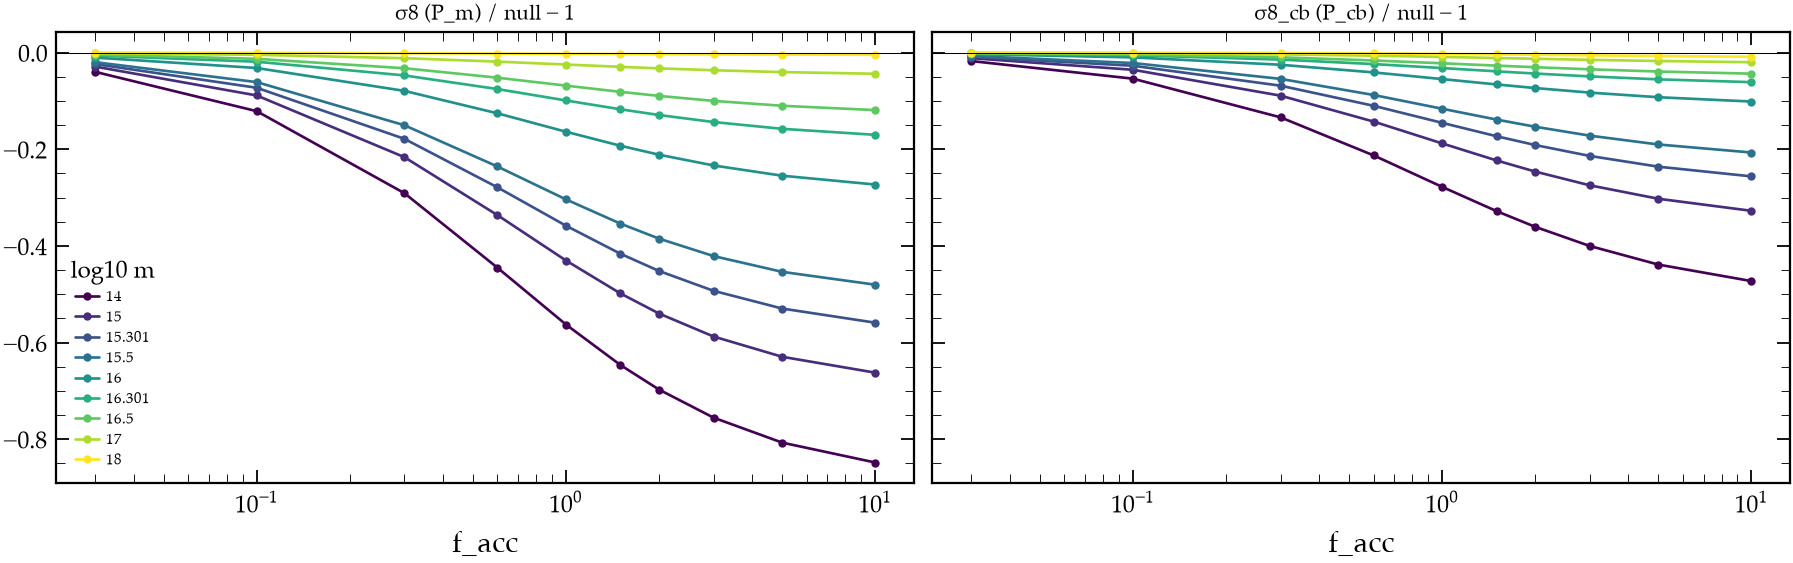

,sigma8 f=1e-06,sigma8_cb f=1e-06,sigma8 f=0.1,sigma8_cb f=0.1,sigma8 f=1,sigma8_cb f=1,sigma8 f=10,sigma8_cb f=10
log10 m,,,,,,,,
14.000,0.8073,0.8107,0.7094,0.7670,0.3530,0.5854,0.1226,0.4274
15.000,0.8073,0.8107,0.7357,0.7819,0.4599,0.6584,0.2726,0.5453
15.301,0.8073,0.8107,0.7486,0.7887,0.5181,0.6929,0.3561,0.6031
15.500,0.8073,0.8107,0.7580,0.7933,0.5620,0.7166,0.4196,0.6431
16.000,0.8073,0.8107,0.7816,0.8027,0.6751,0.7663,0.5869,0.7286
16.301,0.8073,0.8107,0.7920,0.8062,0.7273,0.7848,0.6699,0.7611
16.500,0.8073,0.8107,0.7969,0.8077,0.7521,0.7928,0.7112,0.7754
17.000,0.8073,0.8107,0.8036,0.8096,0.7873,0.8035,0.7719,0.7946
18.000,0.8073,0.8107,0.8069,0.8105,0.8052,0.8086,0.8037,0.8038


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True, constrained_layout=True)
for i, m in enumerate(LOG10_MASSES):
    for ax, name in zip(axes, ('sigma8', 'sigma8_cb')):
        ax.semilogx(F_GRID, [grid[(m, f)][name]/grid[(m, F_NULL)][name] - 1 for f in F_GRID], 'o-', ms=3,
                    color=colour(i), label='{:g}'.format(m))
for ax, name in zip(axes, ('σ8 (P_m)', 'σ8_cb (P_cb)')):
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('f_acc')
    ax.set_title('{} / null − 1'.format(name), fontsize=10)
axes[0].legend(title='log10 m', fontsize=7)
plt.show()

show(pd.DataFrame([{'log10 m': m, **{'{} f={:g}'.format(s, f): grid[(m, f)][s] for f in (F_NULL, 0.1, 1.0, 10.0)
                                    for s in ('sigma8', 'sigma8_cb')}} for m in LOG10_MASSES]).set_index('log10 m'),
     default='{:.4f}')

## 3. Where in k

P_m and P_cb at f_acc = 1 over the null. Below the free-streaming scale the daughters do not cluster, so
P_m/null → (ω_cb/ω_m)² P_cb/null; the dotted line is (ω_cb/ω_m)² alone. Shaded: the scales behind σ8.

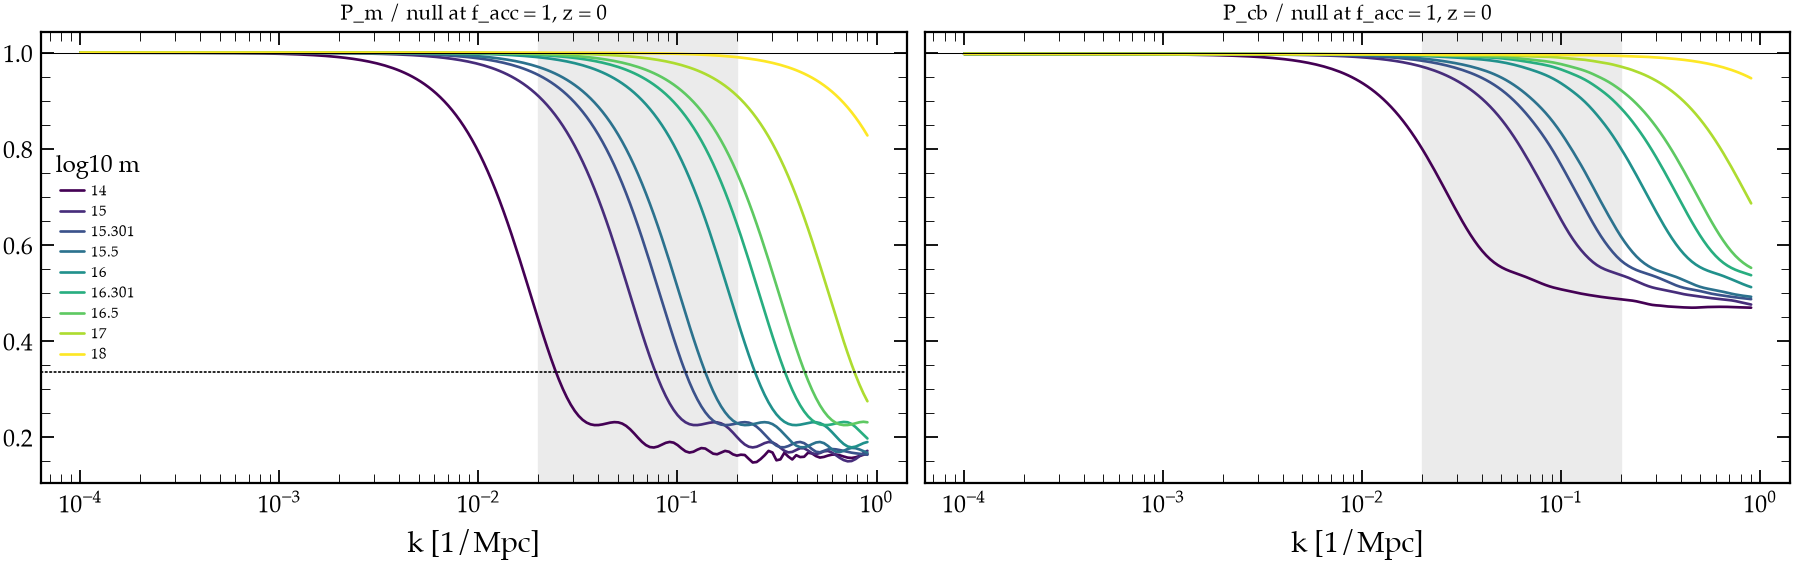

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True, constrained_layout=True)
for i, m in enumerate(LOG10_MASSES):
    a, null = grid[(m, 1.0)], grid[(m, F_NULL)]
    axes[0].semilogx(KK, a['pk_m']/null['pk_m'], color=colour(i), label='{:g}'.format(m))
    axes[1].semilogx(KK, a['pk_cb']/null['pk_cb'], color=colour(i))
omega_b = LCDM['omega_b']
axes[0].axhline(((omega_b + OMEGA_DM_TOT/2)/(omega_b + OMEGA_DM_TOT))**2, color='k', ls=':', lw=0.8)
for ax, name in zip(axes, ('P_m', 'P_cb')):
    ax.axvspan(0.02, 0.2, color='0.92', zorder=0)
    ax.axhline(1, color='k', lw=0.5)
    ax.set_xlabel('k [1/Mpc]')
    ax.set_title('{} / null at f_acc = 1, z = 0'.format(name), fontsize=10)
axes[0].legend(title='log10 m', fontsize=7)
plt.show()

## 4. Δχ² along the ridge

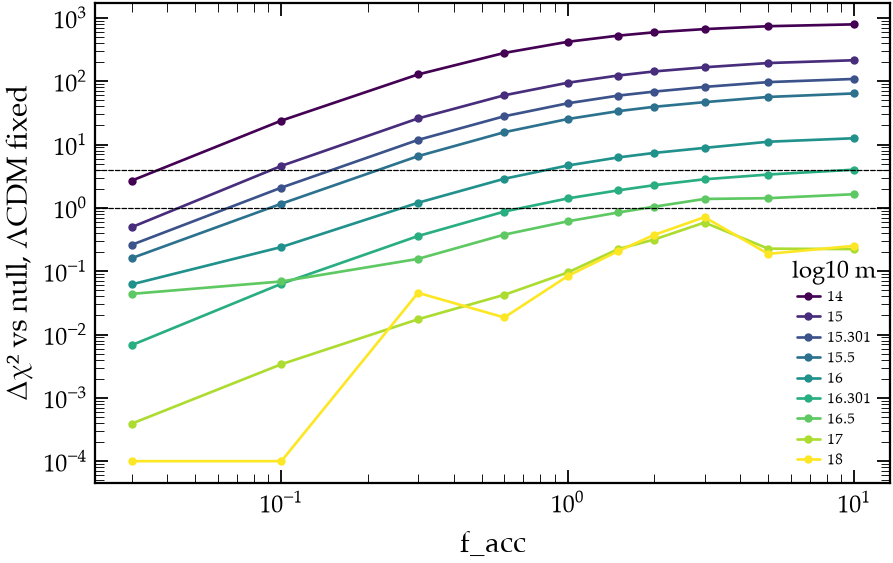

,f at Δχ²=1,f at Δχ²=4,Δχ² f=1,CMB,lensing,BAO
log10 m,,,,,,
14.000,0.03,0.0323,419,62.7,357,2.9e-05
15.000,0.0348,0.0839,94.6,9.25,85.3,4.18e-07
15.301,0.0489,0.124,44.8,4.25,40.6,1.54e-07
15.500,0.0823,0.178,25.3,2.44,22.9,9.11e-08
16.000,0.238,0.826,4.67,0.568,4.1,4.09e-08
16.301,0.677,9.9,1.41,0.257,1.15,3.37e-08
16.500,1.88,inf,0.613,0.134,0.479,3.14e-08
17.000,inf,inf,0.0955,0.0735,0.022,2.85e-08
18.000,inf,inf,0.084,0.0701,0.0139,2.77e-08


In [4]:
def first_crossing(f, y, level):
    """Smallest f where y reaches level, interpolated in log f; inf if never."""
    above = np.nonzero(np.asarray(y) >= level)[0]
    if not len(above):
        return np.inf
    i = above[0]
    return f[0] if i == 0 else float(np.exp(np.interp(level, [y[i - 1], y[i]], np.log([f[i - 1], f[i]]))))


chi2 = {k: chi2_parts(grid[k], grid[(k[0], F_NULL)]) for k in keys if k[1] != F_NULL}
fig, ax = plt.subplots(figsize=(6, 3.8), constrained_layout=True)
rows = []
for i, m in enumerate(LOG10_MASSES):
    tot = [chi2[(m, f)]['total'] for f in F_GRID]
    ax.loglog(F_GRID, np.maximum(tot, 1e-4), 'o-', ms=3, color=colour(i), label='{:g}'.format(m))
    c1 = chi2[(m, 1.0)]
    rows.append({'log10 m': m, 'f at Δχ²=1': first_crossing(F_GRID, tot, 1), 'f at Δχ²=4': first_crossing(F_GRID, tot, 4),
                 'Δχ² f=1': c1['total'], 'CMB': c1['cmb'], 'lensing': c1['lens'], 'BAO': c1['bao']})
for level in (1, 4):
    ax.axhline(level, color='k', ls='--', lw=0.6)
ax.set_xlabel('f_acc')
ax.set_ylabel('Δχ² vs null, ΛCDM fixed')
ax.legend(title='log10 m', fontsize=7)
plt.show()
show(pd.DataFrame(rows).set_index('log10 m'))

## 5. Emulator σ8 against CLASS

For each current chain from 10¹⁵ GeV up, ten samples at evenly spaced f̃ quantiles are run through CLASS
with that chain's own settings (`log.param`: DE sink on, s = 0.25), and CLASS σ8 is compared with the
`sigma8` the emulator wrote into the chain. σ8 is one emulated output, so agreement does not prove the
C_ℓ right, but a disagreement localizes where the emulator is off.

30 new CLASS runs in 325 s


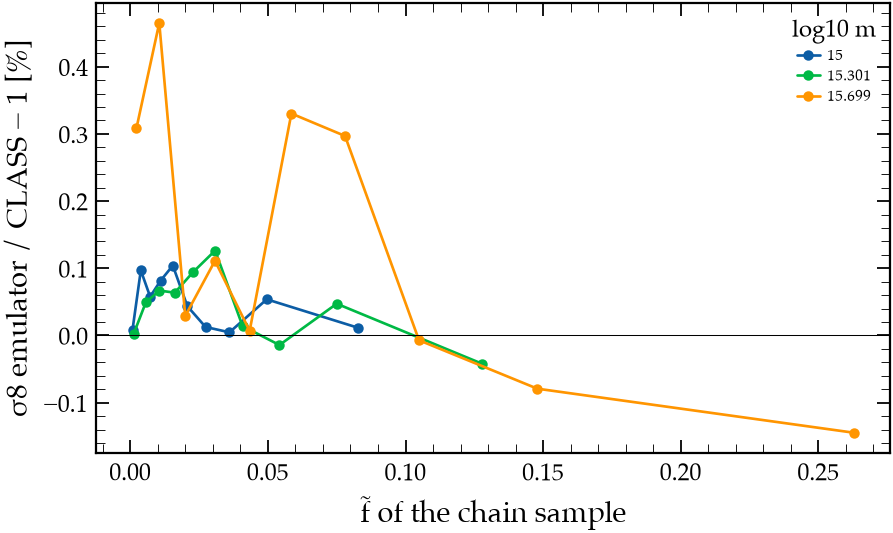

,median,max_abs
log10 m,,
15.000,+0.05%,+0.10%
15.301,+0.05%,+0.13%
15.699,+0.07%,+0.47%


In [5]:
COSMO = ('omega_b', 'omega_dm_tot', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio', 'f_tilde')
picks, jobs = [], []
for d in mass_dirs(chains_dir('k12.1a0.133')):
    if float(d.name) < 15:
        continue
    s, settings = load_chain(d), chain_settings(d)
    order = np.argsort(s['f_tilde'])
    cdf = np.cumsum(s['weight'][order])
    for q in np.linspace(0.03, 0.97, 10):
        i = order[min(np.searchsorted(cdf, q*cdf[-1]), len(order) - 1)]
        picks.append({'log10 m': float(d.name), 'f_tilde': s['f_tilde'][i], 'sigma8 emulator': s['sigma8'][i]})
        jobs.append({**settings, **{k: float(s[k][i]) for k in COSMO}})
emu = pd.DataFrame(picks)
emu['sigma8 CLASS'] = [r.get('sigma8', np.nan) for r in RunCache('14_chain_cache.pkl', workers=8).many(jobs)]
emu['emulator / CLASS − 1'] = emu['sigma8 emulator']/emu['sigma8 CLASS'] - 1

fig, ax = plt.subplots(figsize=(6, 3.6), constrained_layout=True)
for m, e in emu.groupby('log10 m'):
    ax.plot(e['f_tilde'], 100*e['emulator / CLASS − 1'], 'o-', ms=4, label='{:g}'.format(m))
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('f̃ of the chain sample')
ax.set_ylabel('σ8 emulator / CLASS − 1 [%]')
ax.legend(title='log10 m', fontsize=7)
plt.show()
show(emu.groupby('log10 m')['emulator / CLASS − 1'].agg(median='median', max_abs=lambda v: np.abs(v).max()),
     default='{:+.2%}')